In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/train.csv')
df.head( )


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Column Types

- **Numerical** - Age,Fare,PassengerId
- **Categorical** - Survived, Pclass, Sex, SibSp, Parch,Embarked
- **Mixed** - Name, Ticket, Cabin



### Univarite Analysis on Numerical Columns

### Age

**conclusions**

- Age is normally(almost) distributed
- 19% of the values are missing
- There are some outliers


In [ ]:
df['Age'].describe( )

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


<Axes: ylabel='Frequency'>

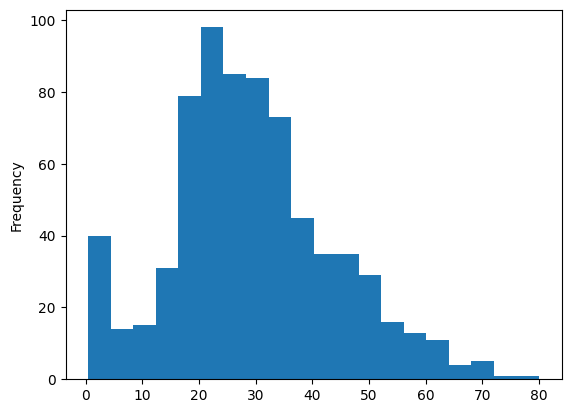

In [ ]:
df['Age'].plot(kind='hist',bins=20)

np.float64(0.38910778230082704)

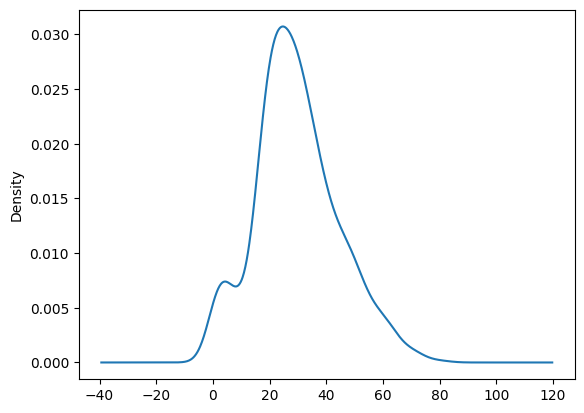

In [ ]:
df['Age'].plot(kind='kde')
df['Age'].skew( )

<Axes: >

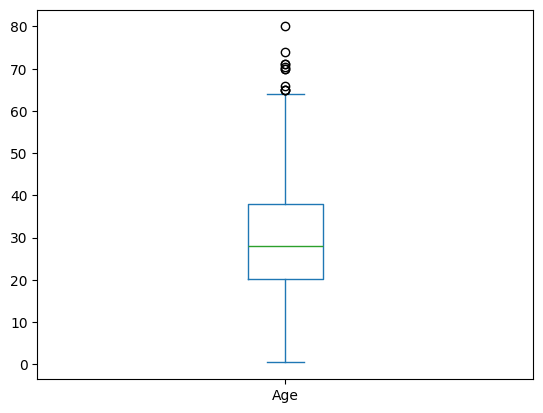

In [ ]:
df['Age'].plot(kind='box')

In [ ]:
df[df['Age']>60]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,B30,C
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
170,171,0,1,"Van der hoef, Mr. Wyckoff",male,61.0,0,0,111240,33.5000,B19,S
252,253,0,1,"Stead, Mr. William Thomas",male,62.0,0,0,113514,26.5500,C87,S
275,276,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.0,1,0,13502,77.9583,D7,S
280,281,0,3,"Duane, Mr. Frank",male,65.0,0,0,336439,7.7500,NaN,Q
326,327,0,3,"Nysveen, Mr. Johan Hansen",male,61.0,0,0,345364,6.2375,NaN,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S


In [ ]:
df['Age'].isnull( ).sum( )/len(df['Age'])*100

np.float64(19.865319865319865)

### Fare

**conclusions**

- The data is highly(positively) skewed
- Fare col actually contains the group fare and not the individual fare
- We need to create a new col called individual fare
- There are some outliers

In [ ]:
df['Fare'].describe( )

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


<Axes: ylabel='Frequency'>

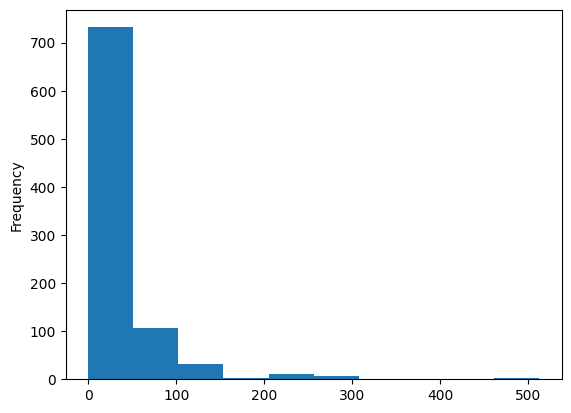

In [ ]:
df['Fare'].plot(kind='hist')

np.float64(4.787316519674893)

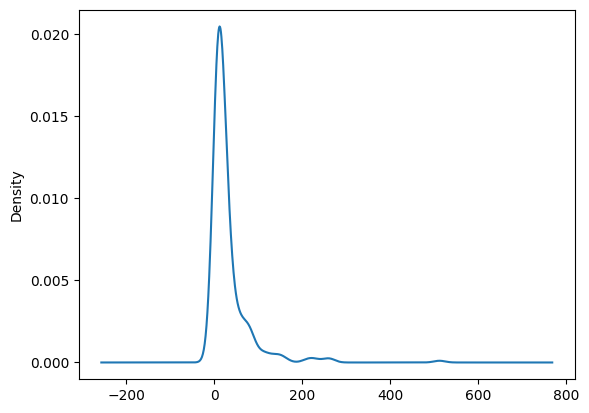

In [ ]:
df['Fare'].plot(kind='kde')
df['Fare'].skew( )

<Axes: >

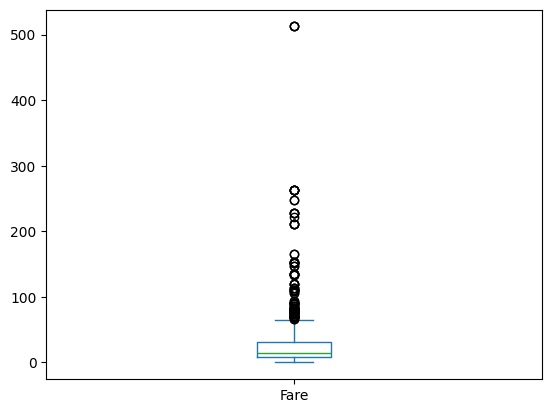

In [ ]:
df['Fare'].plot(kind='box')

In [ ]:
df[df['Fare']>200]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.0,0,1,PC 17558,247.5208,B58 B60,C
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
299,300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.0,0,1,PC 17558,247.5208,B58 B60,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
377,378,0,1,"Widener, Mr. Harry Elkins",male,27.0,0,2,113503,211.5000,C82,C
380,381,1,1,"Bidois, Miss. Rosalie",female,42.0,0,0,PC 17757,227.5250,NaN,C
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S


In [ ]:
df['Fare'].isnull().sum()

np.int64(0)

### Univarite Analysis on Categorical Columns

### Pclass

**conclusions**

- Parch and SibSp cols can be merged to form a new col call family_size
- Create a new col called is_alone
- Suprisingly 1 st class has more people than 2 nd one
- There are no missing values

In [ ]:
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


<Axes: xlabel='Pclass'>

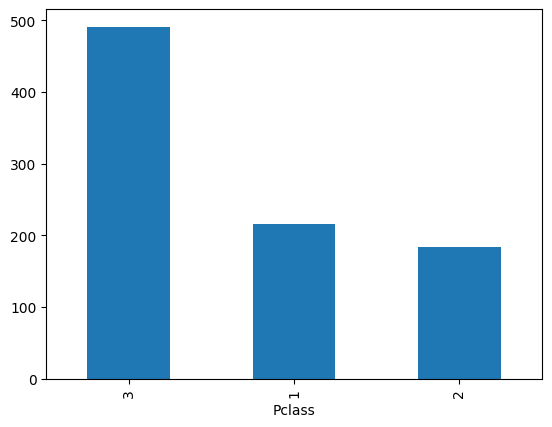

In [ ]:
df['Pclass'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

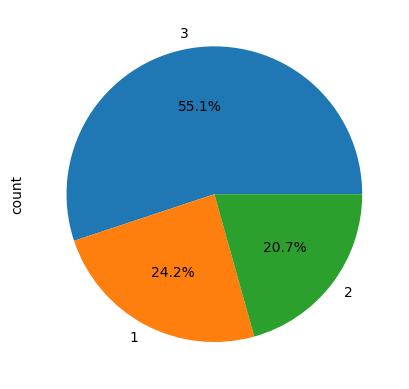

In [ ]:
df['Pclass'].value_counts().plot(kind='pie', autopct='%1.1f%%')

In [ ]:
df['Pclass'].isnull().sum()

np.int64(0)

### Sex

**conclusions**

- Male members are more than females ones around 65 %
- There are no missing values

In [ ]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


<Axes: xlabel='Sex'>

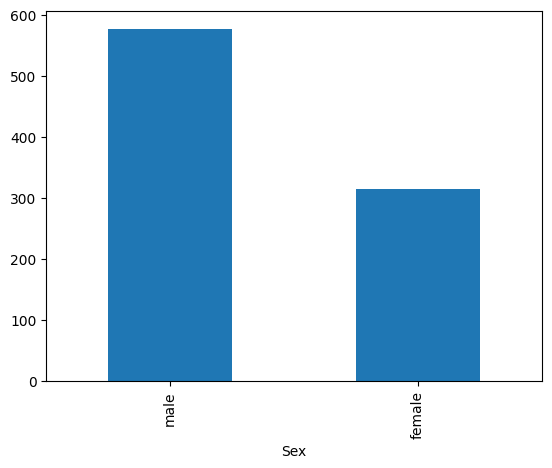

In [ ]:
df['Sex'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

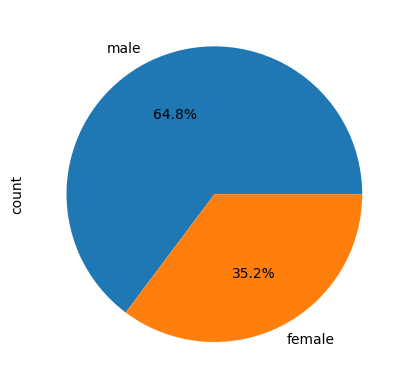

In [ ]:
df['Sex'].value_counts().plot(kind='pie', autopct='%1.1f%%')

In [ ]:
df['Sex'].isnull().sum()

np.int64(0)

### Embarked

**conclusions**

- Most of the people(around 72%) boarded from Southampton
- There are 2 missing values

In [ ]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


<Axes: xlabel='Embarked'>

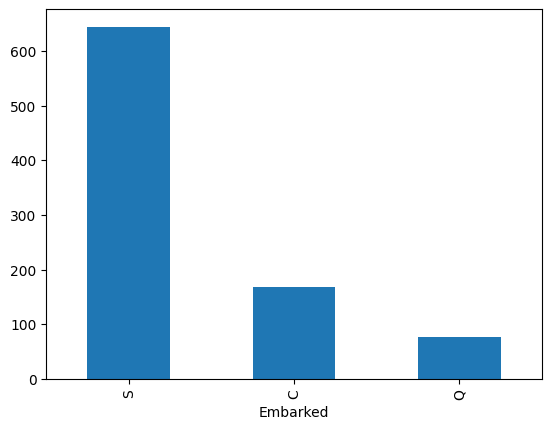

In [ ]:
df['Embarked'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

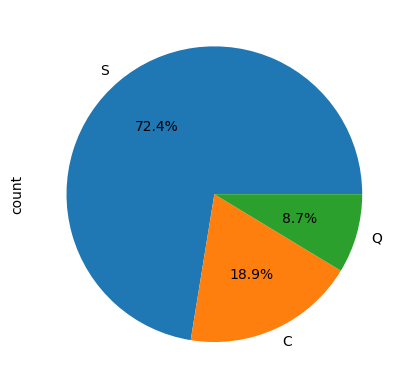

In [ ]:
df['Embarked'].value_counts().plot(kind='pie', autopct='%1.1f%%')

In [ ]:
df['Embarked'].isnull().sum()

np.int64(2)

### Survived

**conclusions**

- Around 38 % people did survived
- There are no missing values

In [ ]:
df['Survived'].value_counts( )

,count
Survived,
0,549
1,342


<Axes: xlabel='Survived'>

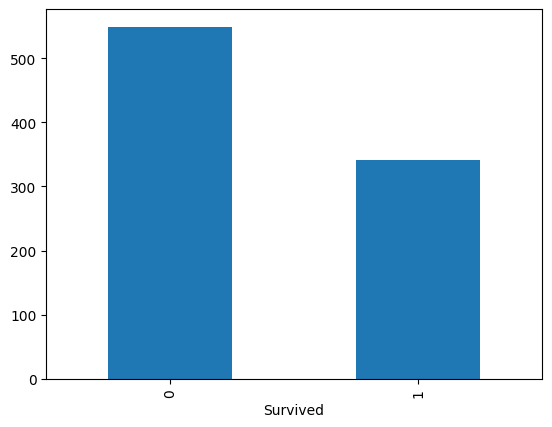

In [ ]:
df['Survived'].value_counts( ).plot(kind='bar')

<Axes: ylabel='count'>

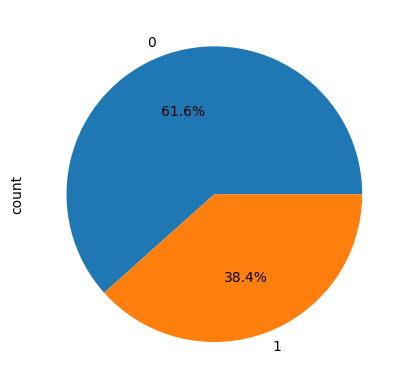

In [ ]:
df['Survived'].value_counts( ).plot(kind='pie',autopct='%1.1f%%')

In [ ]:
df['Survived'].isnull( ).sum( )

np.int64(0)

### Bivarite Analysis

### Categorical vs Categorical Columns

### Survived vs Pclass

**Conclusions**

- Maximum percentage of people survived from the 1st class followed by 2nd and 3rd

In [ ]:
pd.crosstab(df['Survived'],df['Pclass'],normalize='columns')*100

Pclass,1,2,3
Survived,,,
0,37.037037,52.717391,75.763747
1,62.962963,47.282609,24.236253


<Axes: xlabel='Pclass', ylabel='Survived'>

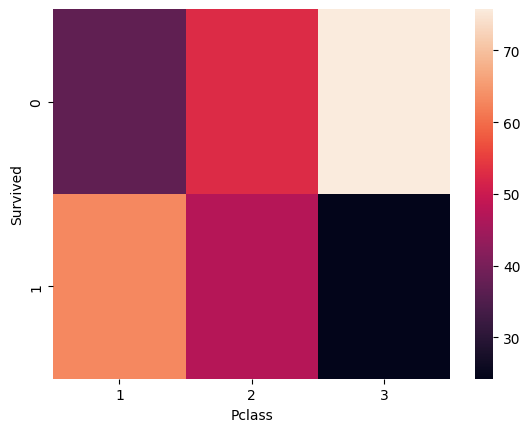

In [ ]:
sns.heatmap(pd.crosstab(df['Survived'],df['Pclass'],normalize='columns')*100)

<Axes: xlabel='Survived'>

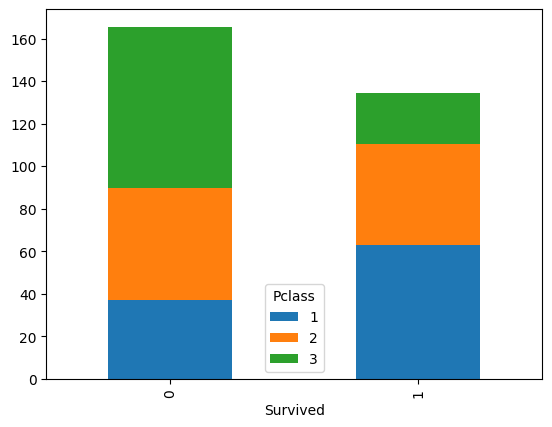

In [ ]:
(pd.crosstab(df['Survived'],df['Pclass'],normalize='columns')*100).plot(kind='bar',stacked=True)

### Survived vs Sex

**Conclusions**

- Females had a much better chance of surviving almost 75 percent of females survived the incident

In [ ]:
pd.crosstab(df['Survived'],df['Sex'],normalize='columns')*100

Sex,female,male
Survived,,
0,25.796178,81.109185
1,74.203822,18.890815


<Axes: xlabel='Sex', ylabel='Survived'>

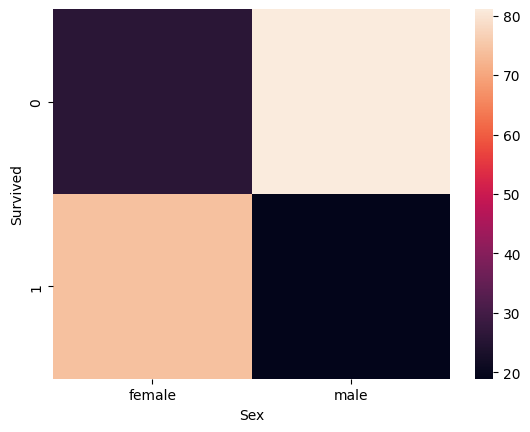

In [ ]:
sns.heatmap(pd.crosstab(df['Survived'],df['Sex'],normalize='columns')*100)

<Axes: xlabel='Survived'>

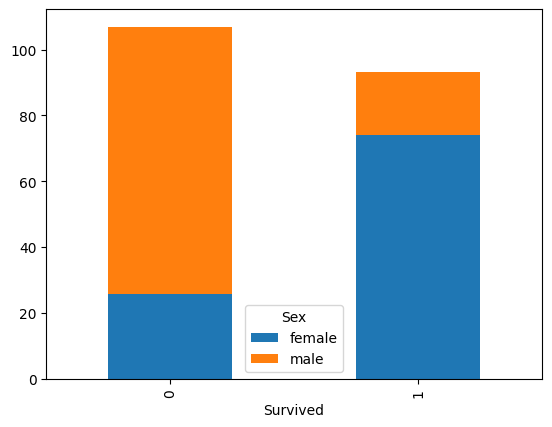

In [ ]:
(pd.crosstab(df['Survived'],df['Sex'],normalize='columns')*100).plot(kind='bar',stacked=True)

### Survived vs Embarked

**Conclusions**

- The people who boarded from the Cherbourg port had a significantly higher chance(~55%) to survive as compared to other 2 ports  

In [ ]:
pd.crosstab(df['Survived'],df['Embarked'],normalize='columns')*100

Embarked,C,Q,S
Survived,,,
0,44.642857,61.038961,66.304348
1,55.357143,38.961039,33.695652


<Axes: xlabel='Embarked', ylabel='Survived'>

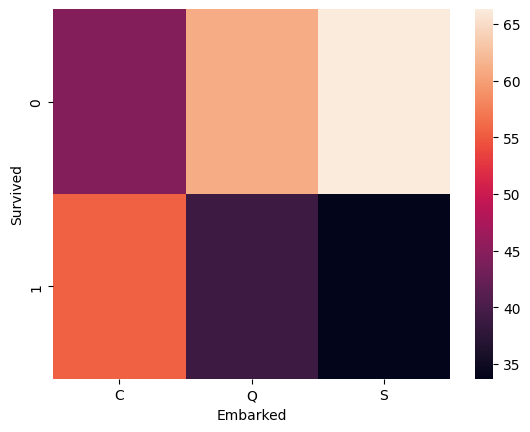

In [ ]:
sns.heatmap(pd.crosstab(df['Survived'],df['Embarked'],normalize='columns')*100)

<Axes: xlabel='Survived'>

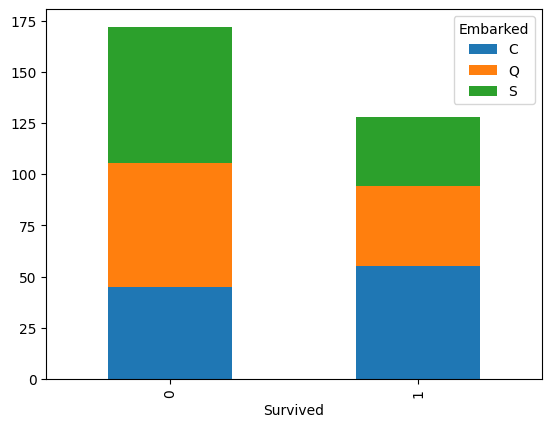

In [ ]:
(pd.crosstab(df['Survived'],df['Embarked'],normalize='columns')*100).plot(kind='bar',stacked=True)

### Embarked vs Pclass

**Conclusions**

- Most of the 1st class people boarded from Port Cherbourg (~50%)
- From this we can conclude that is the reason of a higher rate of survival of people who boarded from Cherbourg port

In [ ]:
pd.crosstab(df['Pclass'],df['Embarked'], normalize='columns') * 100

Embarked,C,Q,S
Pclass,,,
1,50.595238,2.597403,19.720497
2,10.119048,3.896104,25.465839
3,39.285714,93.506494,54.813665


<Axes: xlabel='Pclass', ylabel='Embarked'>

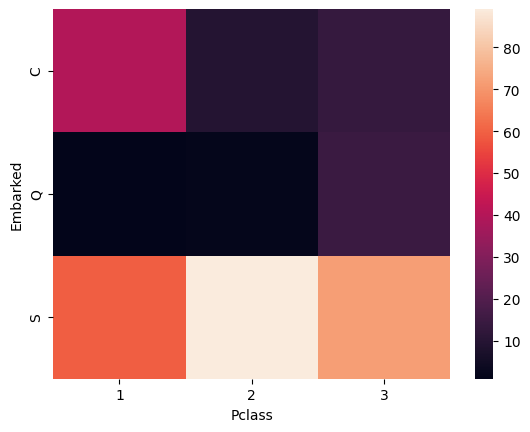

In [ ]:
sns.heatmap(pd.crosstab(df['Embarked'], df['Pclass'], normalize='columns') * 100)

<Axes: xlabel='Embarked'>

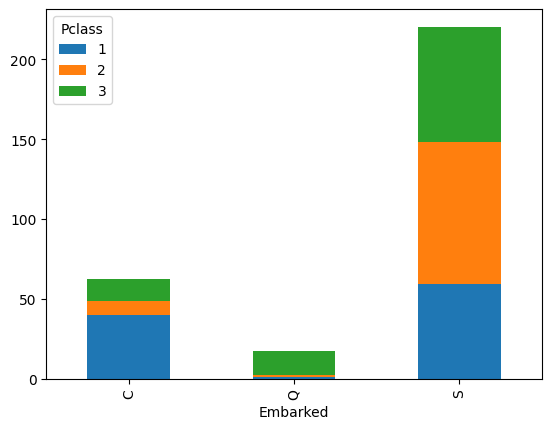

In [ ]:
(pd.crosstab(df['Embarked'], df['Pclass'], normalize='columns') * 100).plot(kind='bar', stacked=True)

### Numerical vs Categorical  Columns

### Survived vs Age

**Conclusions**

- The child age group (0-10) has a higher chance of surviving
- Once you cross that group the the chances of not surviving increase significantly
- We can also see that there is a little more chance of surving in the age group 40 to 50 as there are more 1 st class members in it
- People with age > 60 have a lesser chance to survive

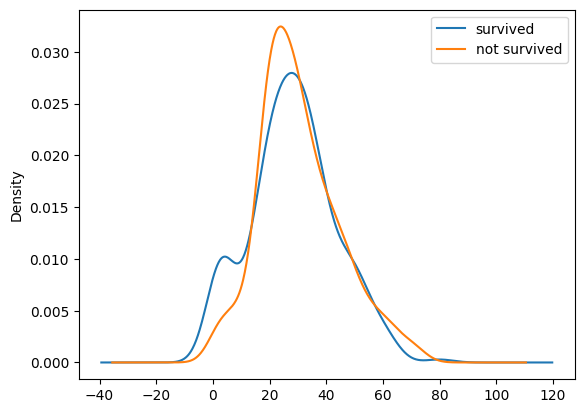

In [ ]:
df[df['Survived']==1]['Age'].plot(kind='kde',label='survived')
df[df['Survived']==0]['Age'].plot(kind='kde',label='not survived')
plt.legend( )
plt.show( )




### Feature Engineering

### Fare Column

**Conclusions**

- The people who paid more and belonged to higher class had a more chance of surviving the incident

In [ ]:
df1=pd.read_csv('/content/test.csv')
df=pd.concat([df,df1])
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [ ]:
df['Indiviual_Fare']=df['Fare']/(df['SibSp']+df['Parch']+1)
df['Indiviual_Fare'].describe( )

,Indiviual_Fare
count,2142.000000
mean,21.018906
std,35.710873
min,0.000000
25%,7.550000
50%,8.662500
75%,25.741700
max,512.329200


<Axes: ylabel='Frequency'>

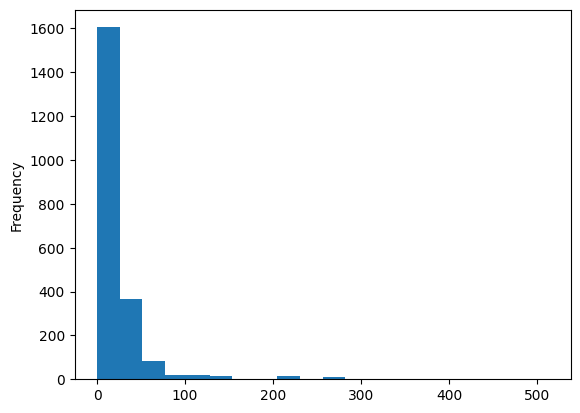

In [ ]:
df['Indiviual_Fare'].plot(kind='hist',bins=20)

<Axes: >

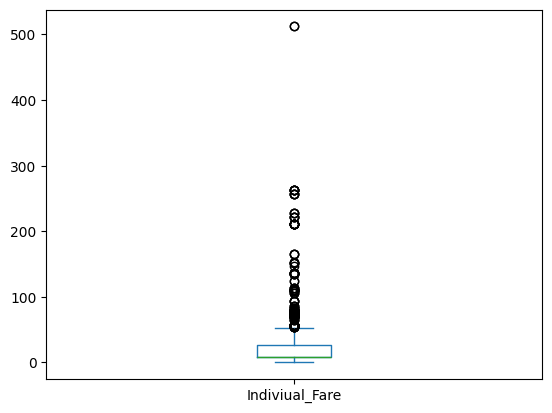

In [ ]:
df['Indiviual_Fare'].plot(kind='box')

In [ ]:
df[df['Indiviual_Fare']>100]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Indiviual_Fare
118,119,0.0,1,"Baxter, Mr. Quigg Edmond",male,24.0,0,1,PC 17558,247.5208,B58 B60,C,123.7604
195,196,1.0,1,"Lurette, Miss. Elise",female,58.0,0,0,PC 17569,146.5208,B80,C,146.5208
258,259,1.0,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C,512.3292
269,270,1.0,1,"Bissette, Miss. Amelia",female,35.0,0,0,PC 17760,135.6333,C99,S,135.6333
299,300,1.0,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.0,0,1,PC 17558,247.5208,B58 B60,C,123.7604
...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,1235,NaN,1,"Cardeza, Mrs. James Warburton Martinez (Charlo...",female,58.0,0,1,PC 17755,512.3292,B51 B53 B55,C,256.1646
371,1263,NaN,1,"Wilson, Miss. Helen Alice",female,31.0,0,0,16966,134.5000,E39 E41,C,134.5000
375,1267,NaN,1,"Bowen, Miss. Grace Scott",female,45.0,0,0,PC 17608,262.3750,NaN,C,262.3750
400,1292,NaN,1,"Bonnell, Miss. Caroline",female,30.0,0,0,36928,164.8667,C7,S,164.8667


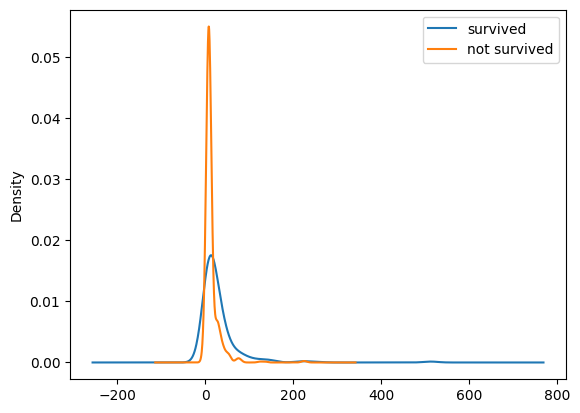

In [ ]:
df[df['Survived']==1]['Indiviual_Fare'].plot(kind='kde',label='survived')
df[df['Survived']==0]['Indiviual_Fare'].plot(kind='kde',label='not survived')
plt.legend( )
plt.show( )

### Family Column

**Conclusions**

- Small families had the best chance of surviving (~57%) followed by alone and large families

In [ ]:
df['Family_Size']=df['SibSp']+df['Parch']+1
df['Family_Size'].value_counts( )

,count
Family_Size,
1,1296
2,383
3,273
4,71
5,36
6,31
7,24
11,19
8,12


In [ ]:
def transform_family_size(num):

  if num == 1:
    return 'alone'
  elif num>1 and num <5:
    return "small"
  else:
    return "large"

df['Family_type']=df['Family_Size'].apply(transform_family_size)
df['Family_type'].value_counts( )

,count
Family_type,
alone,1296
small,727
large,122


In [ ]:
pd.crosstab(df['Survived'],df['Family_type'],normalize='columns')*100

Family_type,alone,large,small
Survived,,,
0.0,69.646182,83.870968,42.123288
1.0,30.353818,16.129032,57.876712


<Axes: xlabel='Survived'>

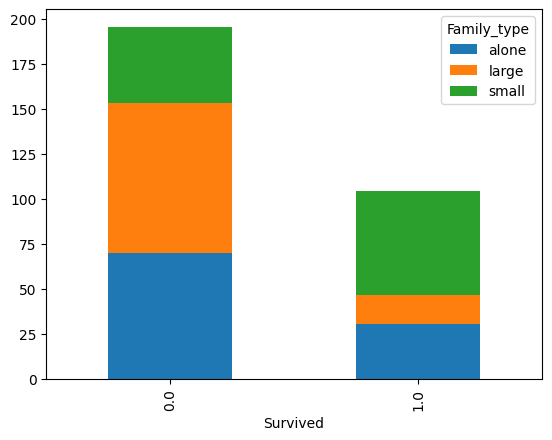

In [ ]:
(pd.crosstab(df['Survived'],df['Family_type'],normalize='columns')*100).plot(kind='bar',stacked=True)

<Axes: xlabel='Family_type', ylabel='Survived'>

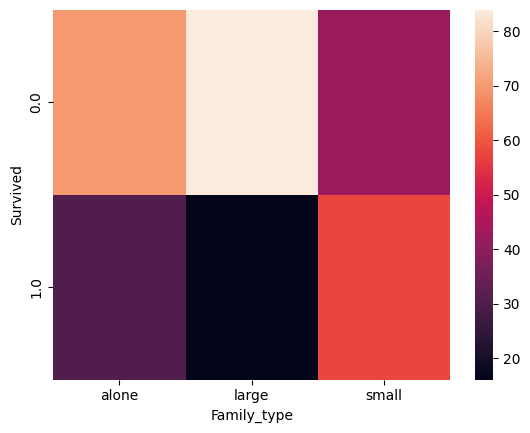

In [ ]:
sns.heatmap(pd.crosstab(df['Survived'],df['Family_type'],normalize='columns')*100)

### Cabin Column

**Conclusions**

- Different Cabins had different chance of survival
- Cabins like B,C,D,E,F,G had more chances of surviving
- Cabins like A,T had lesser chance of surviving

In [ ]:
df['Cabin_class']=df['Cabin'].str.get(0)
df['Cabin_class']=df['Cabin_class'].fillna('M')
df['Cabin_class'].value_counts( )

,count
Cabin_class,
M,1668
C,164
B,101
D,72
E,59
F,37
A,36
G,7
T,1


In [ ]:
pd.crosstab(df['Survived'],df['Cabin_class'],normalize='columns')*100

Cabin_class,A,B,C,D,E,F,G,M,T
Survived,,,,,,,,,
0.0,53.333333,25.531915,40.677966,24.242424,25.0,38.461538,50.0,70.014556,100.0
1.0,46.666667,74.468085,59.322034,75.757576,75.0,61.538462,50.0,29.985444,0.0


Filling missing values

Age column

- Filled the missing values based on mean of gender

In [ ]:
def func(sex):
  if sex=='male':
    return df[df['Sex']=='male']['Age'].mean( )
  else:
    return df[df['Sex']=='female']['Age'].mean( )


df['Age']=df['Age'].fillna(df['Sex'].map(func))